In [1]:

from ucimlrepo import fetch_ucirepo 
import numpyro
import numpyro.distributions as dist
from numpyro import handlers
import jax
import jax.numpy as jnp
import jax.random as random
from jax import vmap
import matplotlib.pyplot as plt
import seaborn as sns
import time
from numpyro.infer import MCMC, NUTS, Predictive, SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoDiagonalNormal
import scipy
import arviz as az

In [2]:
  
# fetch dataset 
concrete_compressive_strength = fetch_ucirepo(id=165) 
  
# data (as pandas dataframes) 
X = concrete_compressive_strength.data.features 
y = concrete_compressive_strength.data.targets 
  
# metadata 
print(concrete_compressive_strength.metadata) 
  
# variable information 
print(concrete_compressive_strength.variables) 


{'uci_id': 165, 'name': 'Concrete Compressive Strength', 'repository_url': 'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength', 'data_url': 'https://archive.ics.uci.edu/static/public/165/data.csv', 'abstract': 'Concrete is the most important material in civil engineering. The concrete compressive strength is a highly nonlinear function of age and ingredients. ', 'area': 'Physics and Chemistry', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 1030, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Concrete compressive strength'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sun Feb 11 2024', 'dataset_doi': '10.24432/C5PK67', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 383, 'type': 'NATIVE', 'title': 'Modeling of strength of high-performance concrete using artificial neural networks', 'authors': 'I. Yeh', 'venue': 'C

In [3]:
def non_lin(x):
    return jnp.tanh(x)

def add_bias(X):
    return jnp.hstack((jnp.ones((X.shape[0],1)), X))
# a two-layer bayesian neural network with computational flow
# given by D_X => D_H => D_H => D_Y where D_H is the number of
# hidden units. (note we indicate tensor dimensions in the comments)
def model(X, Y, D_H, D_Y=1):
    N, D_X = X.shape
    print("Is Y defined?", Y is not None)

    w1 = numpyro.sample("w1", dist.Normal(jnp.zeros((D_X + 1, D_H)), jnp.ones((D_X + 1, D_H))))
    assert w1.shape == (D_X + 1, D_H)
    z1 = non_lin(jnp.matmul(add_bias(X), w1))
    assert z1.shape == (N, D_H)


    w2 = numpyro.sample("w2", dist.Normal(jnp.zeros((D_H + 1, D_H)), jnp.ones((D_H + 1, D_H))))
    assert w2.shape == (D_H + 1, D_H)
    z2 = non_lin(jnp.matmul(add_bias(z1), w2))
    assert z2.shape == (N, D_H)

    w3 = numpyro.sample("w3", dist.Normal(jnp.zeros((D_H + 1, D_Y)), jnp.ones((D_H + 1,D_Y))))
    assert w3.shape == (D_H + 1, D_Y)
    z3 = jnp.matmul(add_bias(z2),w3)
    assert z3.shape == (N, D_Y)


    # Place prior over observation noise (normal inverse gamma distribution)
    prec_obs = numpyro.sample("prec_obs", dist.Gamma(3.0, 1.0))
    sigma_obs = 1.0 / jnp.sqrt(prec_obs)

    # Observed data
    with numpyro.plate("data", N):
        # note we use to_event(1) because each observation has shape (1,)
        numpyro.sample("Y", dist.Normal(z3, sigma_obs).to_event(1), obs=Y)

In [4]:
def predict(m, rng_key, samples, X, D_H):
    if samples is not None:
        m = handlers.substitute(handlers.seed(m, rng_key), samples)
    else:
        m = handlers.seed(m, rng_key)
    # note that Y will be sampled in the model because we pass Y=None here
    model_trace = handlers.trace(m).get_trace(X=X, Y=None, D_H=D_H)
    return model_trace["Y"]["value"]


def plot_distribution(model, rng_key, X, Y, D_H, samples=None):
    #plt.hist(y, histtype="step", alpha=0.3, label="observed")
    sns.kdeplot(Y)
    #plt.hist(trace["Y"]["value"], histtype="step", alpha=0.3, label="simulated")
    sns.kdeplot(predict(model, rng_key, samples, X, D_H))
    plt.legend()

In [5]:
# Infer posterior distribution over weights and noise
def run_inference(model, args, rng_key, X, Y, D_H):
    start = time.time()
    kernel = NUTS(model)
    mcmc = MCMC(
        kernel,
        num_warmup=args.num_warmup,
        num_samples=args.num_samples,
        num_chains=args.num_chains,
        progress_bar=True
    )
    mcmc.run(rng_key, X, Y, D_H)
    mcmc.print_summary()
    print("\nMCMC elapsed time", time.time() - start)
    return mcmc.get_samples(), mcmc


In [6]:
def variational_inference(model, rng_key, X, Y, D_H):
    start = time.time()
    guide = AutoDiagonalNormal(model)
    optimizer = numpyro.optim.Adam(step_size=5e-3)
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
    svi_result = svi.run(rng_key, 2000, X, Y, D_H)
    print("\nVI elapsed time", time.time() - start)
    return svi_result
svi_result = variational_inference(model, random.PRNGKey(9876), jnp.array(X), jnp.array(y), 8)

Is Y defined? True
Is Y defined? True
Is Y defined? True


  0%|          | 0/2000 [00:00<?, ?it/s]

Is Y defined? True


100%|██████████| 2000/2000 [00:02<00:00, 711.61it/s, init loss: 92373.3750, avg. loss [1901-2000]: 5175.7222] 



VI elapsed time 6.322923421859741


In [7]:
class Args():
    num_samples=3000
    num_warmup=1000
    num_chains=1
    num_data=X.shape[0]
    num_hidden=5
    device="cpu"
args = Args()
numpyro.set_platform(args.device)
numpyro.set_host_device_count(args.num_chains)
samples, mcmc = run_inference(model, args, jax.random.PRNGKey(123), jnp.array(X), jnp.array(y), D_H=8)

Is Y defined? True
Is Y defined? True


  0%|          | 0/4000 [00:00<?, ?it/s]

Is Y defined? True


sample: 100%|██████████| 4000/4000 [10:15<00:00,  6.49it/s, 1023 steps of size 6.52e-04. acc. prob=0.55]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
  prec_obs      0.03      0.00      0.03      0.03      0.03      4.56      1.61
   w1[0,0]     -2.48      0.78     -2.54     -3.86     -1.29     16.82      1.01
   w1[0,1]      0.38      0.79      0.47     -0.96      1.71     11.96      1.21
   w1[0,2]      0.16      0.68      0.20     -1.10      1.05      8.53      1.16
   w1[0,3]     -0.12      0.93     -0.30     -1.45      1.48      8.28      1.01
   w1[0,4]      1.16      0.48      1.22      0.29      1.91      3.53      1.90
   w1[0,5]      0.04      1.12      0.17     -1.50      2.21     14.51      1.09
   w1[0,6]     -0.02      0.84     -0.06     -1.51      1.05     20.16      1.03
   w1[0,7]      1.23      0.60      1.29      0.16      2.01      5.15      1.00
   w1[1,0]      0.00      0.00      0.00      0.00      0.00     66.76      1.02
   w1[1,1]      0.23      0.05      0.23      0.15      0.31     18.01      1.00
   w1[1,2]      0.34      0

Is Y defined? True
Is Y defined? True


/home/rasmuslovstad/Programs/assignments/thesis/.venv/lib64/python3.11/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (154) in plot_posterior, generating only 40 plots
  warnings.warn(


array([[<Axes: title={'center': 'prec_obs'}>,
        <Axes: title={'center': 'w1\n0, 0'}>,
        <Axes: title={'center': 'w1\n0, 1'}>,
        <Axes: title={'center': 'w1\n0, 2'}>],
       [<Axes: title={'center': 'w1\n0, 3'}>,
        <Axes: title={'center': 'w1\n0, 4'}>,
        <Axes: title={'center': 'w1\n0, 5'}>,
        <Axes: title={'center': 'w1\n0, 6'}>],
       [<Axes: title={'center': 'w1\n0, 7'}>,
        <Axes: title={'center': 'w1\n1, 0'}>,
        <Axes: title={'center': 'w1\n1, 1'}>,
        <Axes: title={'center': 'w1\n1, 2'}>],
       [<Axes: title={'center': 'w1\n1, 3'}>,
        <Axes: title={'center': 'w1\n1, 4'}>,
        <Axes: title={'center': 'w1\n1, 5'}>,
        <Axes: title={'center': 'w1\n1, 6'}>],
       [<Axes: title={'center': 'w1\n1, 7'}>,
        <Axes: title={'center': 'w1\n2, 0'}>,
        <Axes: title={'center': 'w1\n2, 1'}>,
        <Axes: title={'center': 'w1\n2, 2'}>],
       [<Axes: title={'center': 'w1\n2, 3'}>,
        <Axes: title={'center

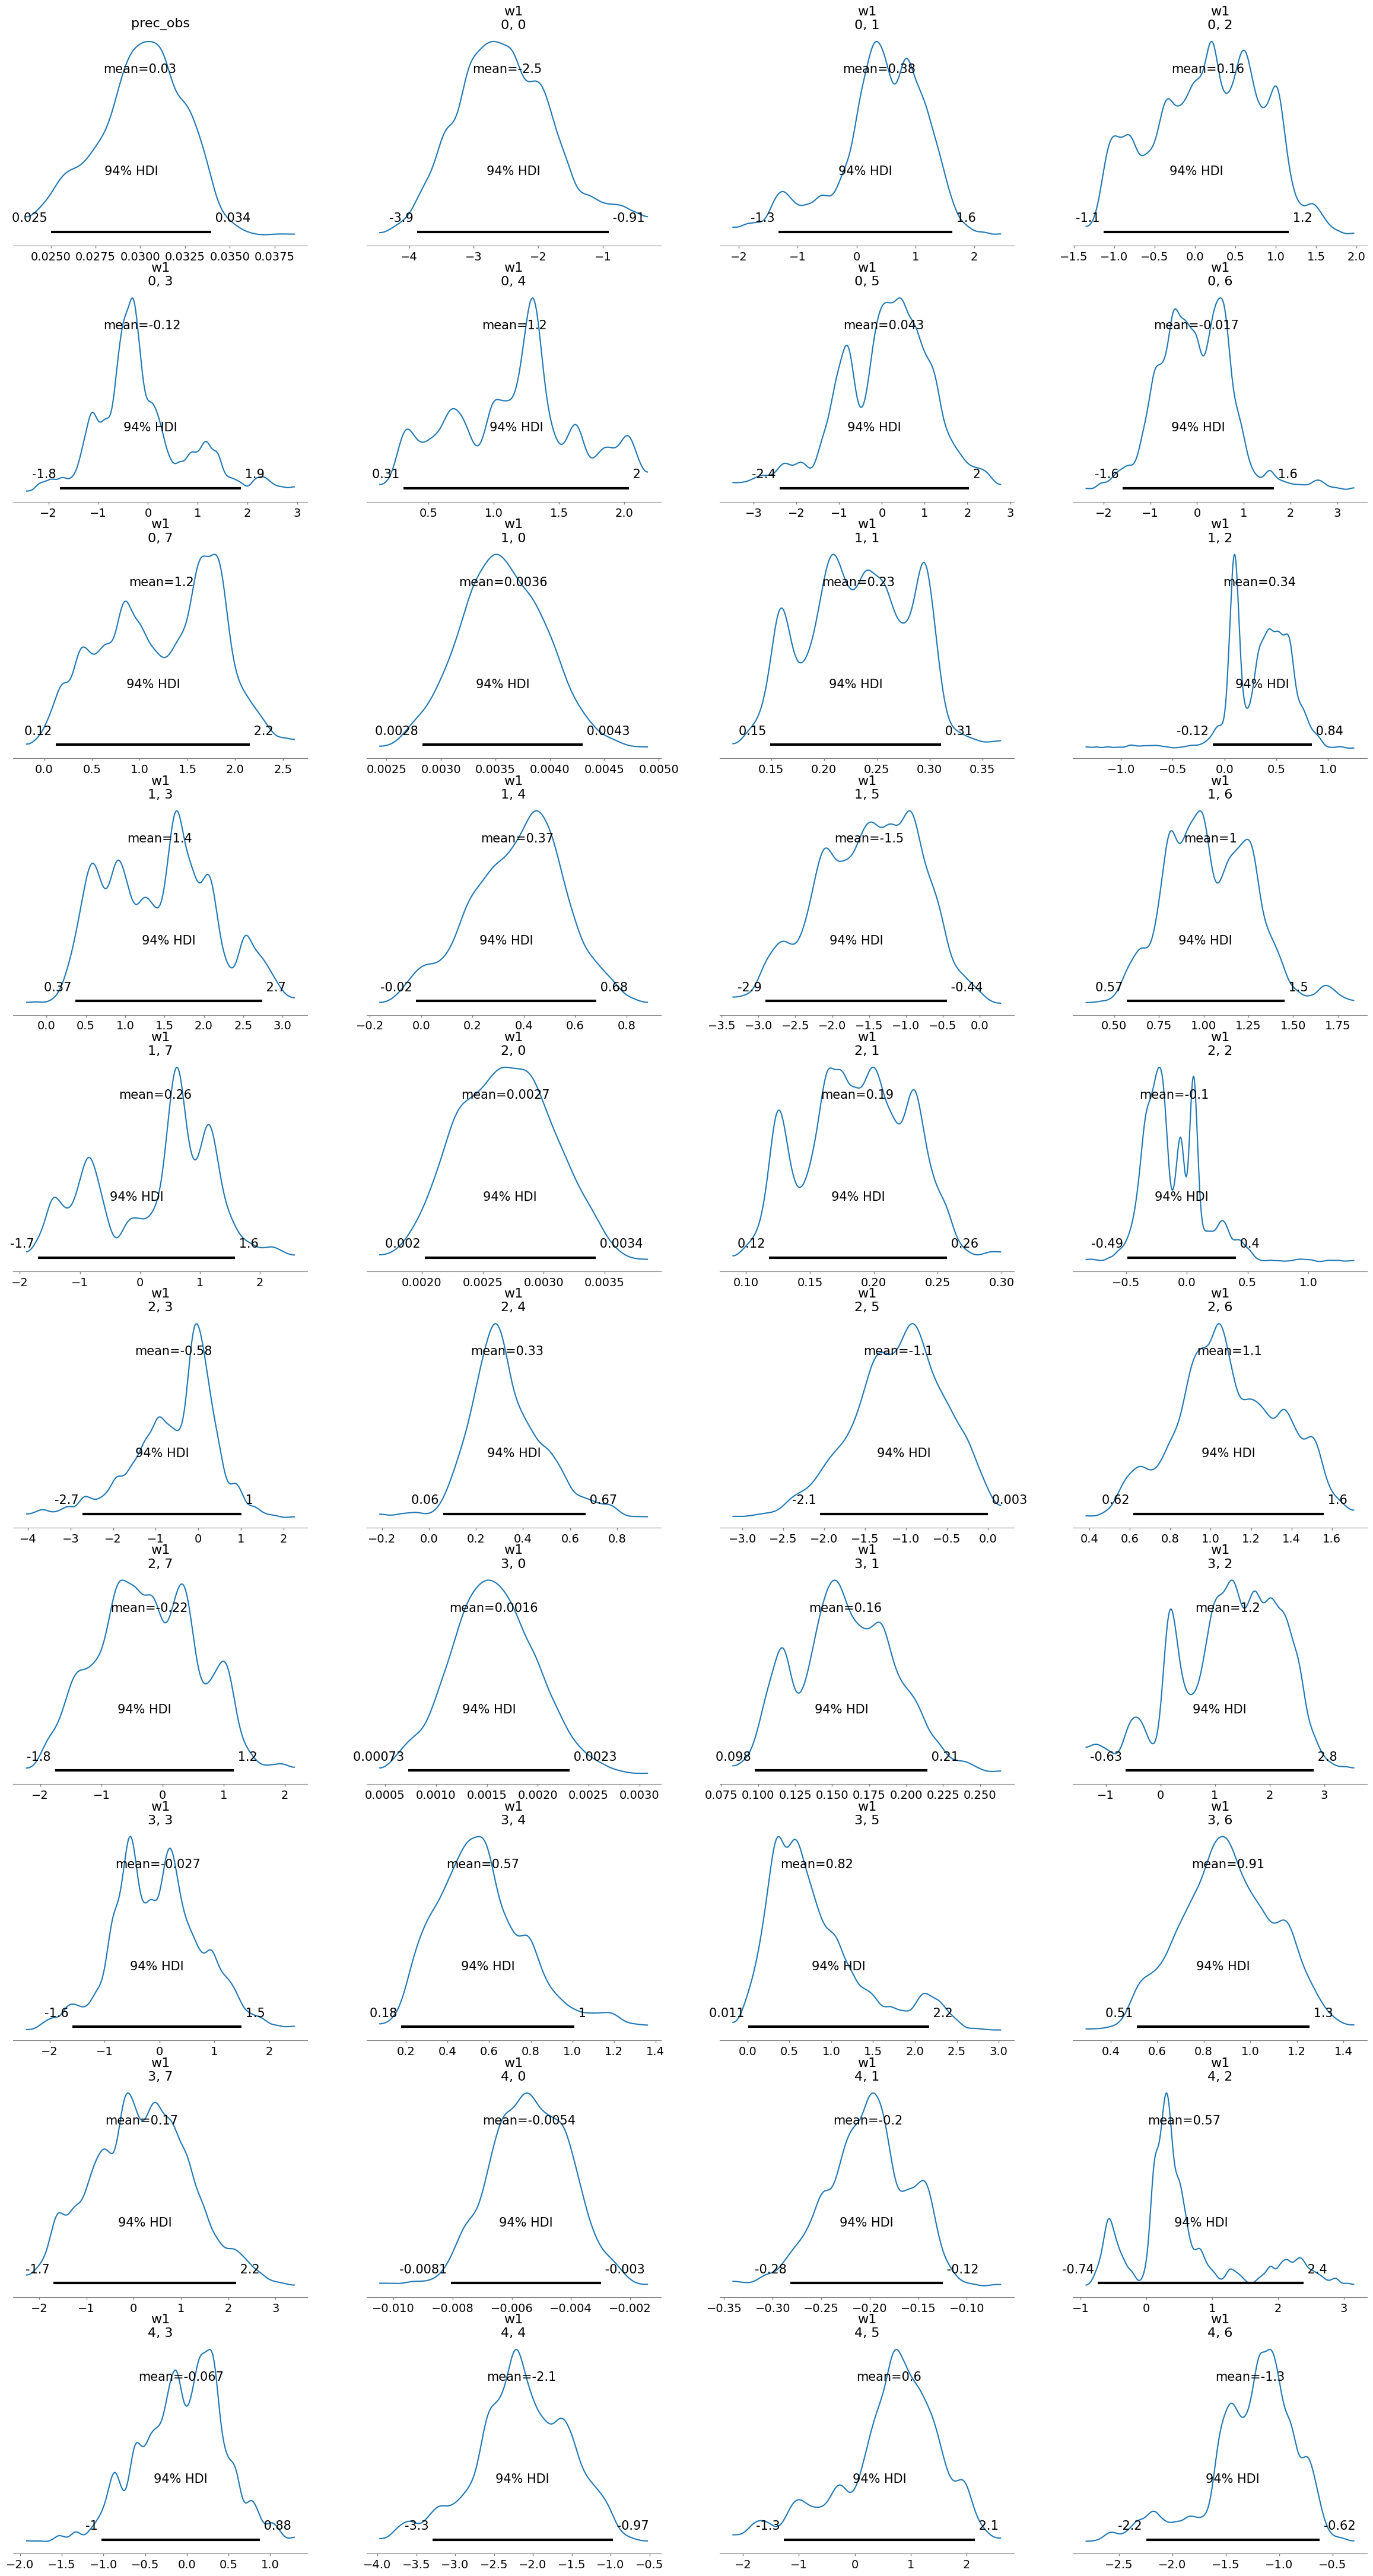

In [8]:
inference_data = az.from_numpyro(mcmc)
az.plot_posterior(inference_data)

Is Y defined? False


/home/rasmuslovstad/Programs/assignments/thesis/.venv/lib64/python3.11/site-packages/arviz/data/base.py:272: UserWarning: More chains (3000) than draws (1030). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


<Axes: title={'center': 'predictive_samples\n0'}>

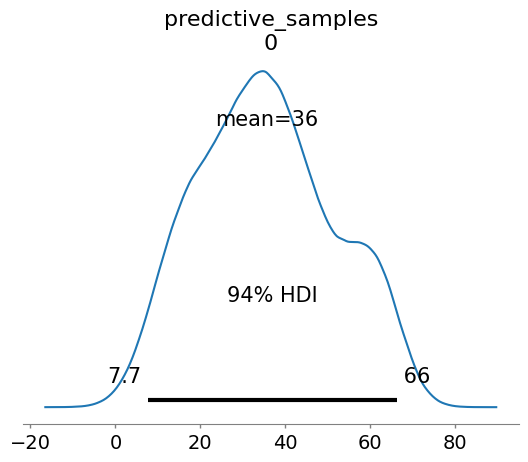

In [9]:
predictive = Predictive(model, samples)
rng_key_predict = random.PRNGKey(1234)
posterior_predictive_samples = predictive(rng_key_predict, jnp.array(X), None, 8)

output_samples = posterior_predictive_samples["Y"]

# Convert to InferenceData for ArviZ
idata = az.from_dict(
    posterior_predictive={"predictive_samples": output_samples},
)

# Plot posterior predictive distribution
az.plot_posterior(idata.posterior_predictive)

Is Y defined? False
(2, 1030)


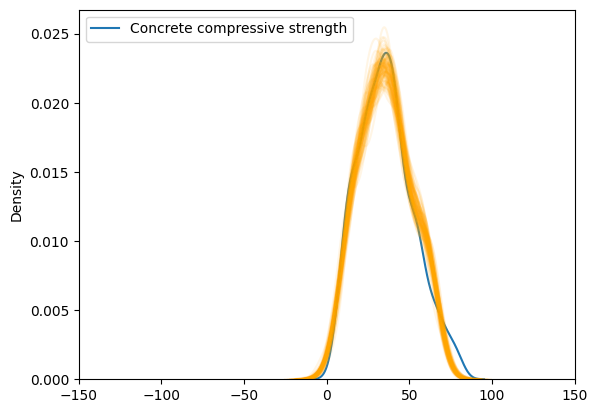

In [10]:
#plot_distribution(model, random.PRNGKey(12), jnp.array(X), jnp.array(y), D_H=2, samples=samples)
import scipy.stats


vmap_args = (
    samples,
    random.split(rng_key_predict, args.num_samples * args.num_chains),
)
predictions = vmap(
    lambda samples, rng_key: predict(model, rng_key, samples, jnp.array(X), 8)
)(*vmap_args)
predictions = predictions[..., 0]
mean_prediction = jnp.mean(predictions, axis=0)
#std_prediction = jnp.std(predictions, axis=0)
percentiles = jnp.percentile(predictions, jnp.array([5.0, 95.0]), axis=0)
print(percentiles.shape)
plt.xlim(-150, 150)
sns.kdeplot(y)
#sns.kdeplot(percentiles[0], alpha=0.1, color="green")
#sns.kdeplot(percentiles[1], alpha=0.1, color="red")
for i in range(100):
    sns.kdeplot(predictions[i], alpha=0.1, color="orange")
#plt.plot(jnp.arange(-10, 100), scipy.stats.multivariate_normal.pdf(jnp.arange(-10, 100), jnp.mean(mean_prediction), jnp.mean(std_prediction)))

In [11]:
#plot_distribution(model, random.PRNGKey(12), jnp.array(X), jnp.array(y), D_H=2, samples=samples)
import scipy.stats



predictive = Predictive(AutoDiagonalNormal(model), params=svi_result.params, num_samples=100)
predictions = predictive(random.PRNGKey(3123), jnp.array(X), None, 8)
predictions = predictions[..., 0]
mean_prediction = jnp.mean(predictions, axis=0)
#std_prediction = jnp.std(predictions, axis=0)
percentiles = jnp.percentile(predictions, jnp.array([5.0, 95.0]), axis=0)
print(percentiles.shape)
plt.xlim(-150, 150)
sns.kdeplot(y)
#sns.kdeplot(percentiles[0], alpha=0.1, color="green")
#sns.kdeplot(percentiles[1], alpha=0.1, color="red")
for i in range(100):
    sns.kdeplot(predictions[i], alpha=0.1, color="orange")
#plt.plot(jnp.arange(-10, 100), scipy.stats.multivariate_normal.pdf(jnp.arange(-10, 100), jnp.mean(mean_prediction), jnp.mean(std_prediction)))

Is Y defined? False
Is Y defined? False


TypeError: cannot reshape array of shape (154,) (size 154) into shape (1030, 1) (size 1030)